In [9]:
import mediacloud.api as mc
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os


In [10]:
API_KEY = "52589ec0fbb30ff9fb5c50ed7e3829f88b07f362"
COLLECTION_ID = 34411583      # Canada - National
START_YEAR = 2015
END_YEAR = 2025
LANGUAGE_FILTER = "language:en"
OUTPUT_DIR = "../../data/headlines_all"

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Fetch sources in the collection

Get all 108 sources from the Canada - National collection and their metadata.


In [11]:
directory = mc.DirectoryApi(API_KEY)
search = mc.SearchApi(API_KEY)

# Fetch all sources (108 total, paginate with limit=200 to get in one shot)
page = directory.source_list(collection_id=COLLECTION_ID, limit=200)
sources = page["results"]
print(f"Total sources in collection: {page['count']}")
print(f"Fetched: {len(sources)}")

df_sources = pd.DataFrame(sources)[["id", "name", "label", "primary_language", "pub_country", "pub_state", "stories_per_week", "stories_total"]]
df_sources.head(10)


Total sources in collection: 108
Fetched: 108


,id,name,label,primary_language,pub_country,pub_state,stories_per_week,stories_total
0,32313,thespec.com,thespec.com,en,None,None,2936,340713
1,380429,niagarafallsreview.ca,Niagara Falls Review,en,CAN,CA-ON,2881,329382
2,232229,wellandtribune.ca,wellandtribune.ca,en,CAN,CA-ON,2881,329629
3,380305,therecord.com,The Record.com,en,CAN,CA-ON,2833,330671
4,18540,thestar.com,thestar.com,en,None,None,2359,989461
5,935665,winnipegfreepress.com,winnipegfreepress.com,en,None,None,1668,679917
6,110768,radio-canada.ca,ici.radio-canada.ca,fr,CAN,CA-QC,1377,517344
7,144282,journaldequebec.com,journaldequebec.com,fr,CAN,CA-QC,1183,339616
8,184045,journaldemontreal.com,journaldemontreal.com,fr,CAN,CA-QC,1182,340194
9,91511,medicinehatnews.com,medicinehatnews.com,en,CAN,CA-AB,1149,209483


## 2. Coverage counts per source per year (2015–2025)

Query `stories_by_source_over_interval` with `interval='year'` and `language:en` filter once per year — 11 API calls total for all 108 sources.


In [12]:
all_records = []

for year in range(START_YEAR, END_YEAR + 1):
    start = dt.date(year, 1, 1)
    end = dt.date(year, 12, 31)
    results = search.stories_by_source_over_interval(
        query=LANGUAGE_FILTER,
        start_date=start,
        end_date=end,
        collection_ids=[COLLECTION_ID],
        interval="year"
    )
    for r in results:
        all_records.append({
            "source": r["media_name"],
            "year": year,
            "matching_stories": r["matching_stories"],
            "total_stories": r["total_stories"],
        })
    print(f"{year}: {len(results)} sources, total English stories = {sum(r['matching_stories'] for r in results):,}")

df = pd.DataFrame(all_records)
print(f"\nTotal records: {len(df)}")
df.head()


2015: 108 sources, total English stories = 422,759
2016: 108 sources, total English stories = 489,313
2017: 108 sources, total English stories = 802,397
2018: 108 sources, total English stories = 868,109
2019: 108 sources, total English stories = 1,005,437
2020: 108 sources, total English stories = 940,330
2021: 108 sources, total English stories = 948,100
2022: 108 sources, total English stories = 830,645
2023: 108 sources, total English stories = 587,859
2024: 108 sources, total English stories = 1,119,849
2025: 108 sources, total English stories = 1,203,081

Total records: 1188


,source,year,matching_stories,total_stories
0,foundintran.substack.com,2015,0,0
1,christianweek.org,2015,1,1
2,windsorstar.com,2015,26,26
3,whitehorsestar.com,2015,0,0
4,leaderpost.com,2015,4,4


In [13]:
# Quick sanity check - thestar.com coverage over years
df_star = df[df["source"] == "thestar.com"]
print("thestar.com by year:")
print(df_star[["year", "matching_stories", "total_stories"]].to_string(index=False))

# Compare: thestar total_stories from source metadata
thestar_meta = next(s for s in sources if s["name"] == "thestar.com")
print(f"\nthestar.com metadata total stories: {thestar_meta['stories_total']:,}")
print(f"Sum from our yearly query: {df_star['total_stories'].sum():,}")


thestar.com by year:
 year  matching_stories  total_stories
 2015             41453          41453
 2016             36028          36029
 2017             36670          36695
 2018             38955          38961
 2019             99015          99034
 2020             92616          92674
 2021            140401         140493
 2022            114618         114679
 2023             63660          63710
 2024             95213          95226
 2025            114175         114178

thestar.com metadata total stories: 989,461
Sum from our yearly query: 873,132


## 3. Save raw coverage data & compute summary statistics


In [14]:
# Save raw yearly counts
df.to_csv(os.path.join(OUTPUT_DIR, "coverage_per_source_per_year.csv"), index=False)

# Pivot: sources as rows, years as columns
df_pivot = df.pivot(index="source", columns="year", values="matching_stories").fillna(0).astype(int)
df_pivot.to_csv(os.path.join(OUTPUT_DIR, "coverage_pivot.csv"))

# Summary stats per source
YEARS = list(range(START_YEAR, END_YEAR + 1))
N_YEARS = len(YEARS)  # 11

df_summary = df.groupby("source")["matching_stories"].agg(
    total="sum",
    mean="mean",
    std="std",
    min="min",
    max="max",
).round(1)

df_summary["years_active"] = df.groupby("source")["matching_stories"].apply(lambda x: (x > 0).sum())
df_summary["years_sparse"] = df.groupby("source")["matching_stories"].apply(lambda x: ((x > 0) & (x < 500)).sum())
df_summary["cv"] = (df_summary["std"] / df_summary["mean"]).round(3)  # coefficient of variation
df_summary["pct_years_active"] = (df_summary["years_active"] / N_YEARS * 100).round(1)

# Add language info from source metadata
lang_map = {s["name"]: s.get("primary_language", "unknown") for s in sources}
df_summary["primary_language"] = df_summary.index.map(lang_map)

df_summary = df_summary.sort_values("total", ascending=False)
df_summary.to_csv(os.path.join(OUTPUT_DIR, "source_summary.csv"))

print(f"Saved to {OUTPUT_DIR}")
df_summary.head(15)


Saved to ../../data/headlines_all


,total,mean,std,min,max,years_active,years_sparse,cv,pct_years_active,primary_language
source,,,,,,,,,,
thestar.com,872804,79345.8,37430.8,36028,140401,11,0,0.472,100.0,en
ctvnews.ca,805437,73221.5,40564.1,3121,115738,11,0,0.554,100.0,en
winnipegfreepress.com,648170,58924.5,39683.3,33,108446,11,2,0.673,100.0,en
cbc.ca,616446,56040.5,56615.4,5,138817,11,2,1.010,100.0,en
globalnews.ca,568552,51686.5,15288.9,21199,70784,11,0,0.296,100.0,en
nationalpost.com,499193,45381.2,47953.4,0,122825,9,0,1.057,81.8,None
sportsnet.ca,372690,33880.9,15412.4,60,47155,11,1,0.455,100.0,en
thespec.com,288931,26266.5,53582.2,30,156736,11,3,2.040,100.0,en
therecord.com,281396,25581.5,52541.8,12,153623,11,3,2.054,100.0,en


## 4. Visualize: total coverage by source and coverage patterns over time


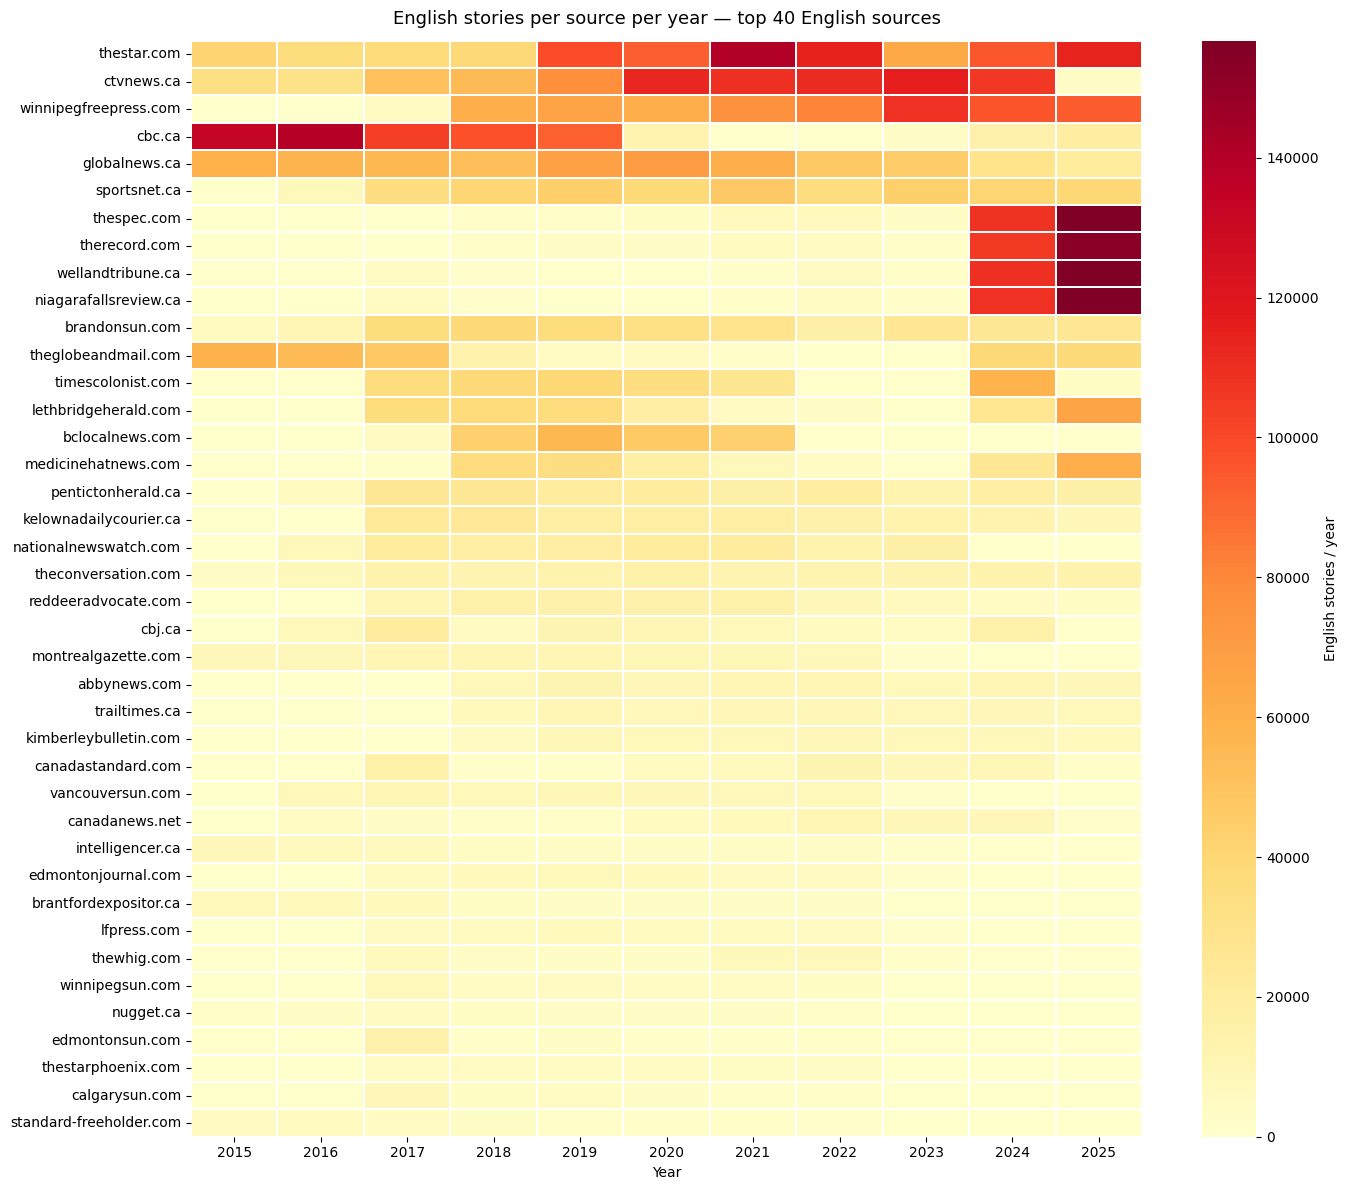

In [16]:
# --- Fig 1: Heatmap of English stories per source per year (top 40 sources) ---
top40 = df_summary[df_summary["primary_language"] == "en"].head(40).index.tolist()
heat_data = df_pivot.loc[top40]
heat_data = heat_data.loc[heat_data.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "English stories / year"},
    fmt=",.0f",
)
ax.set_title("English stories per source per year — top 40 English sources", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


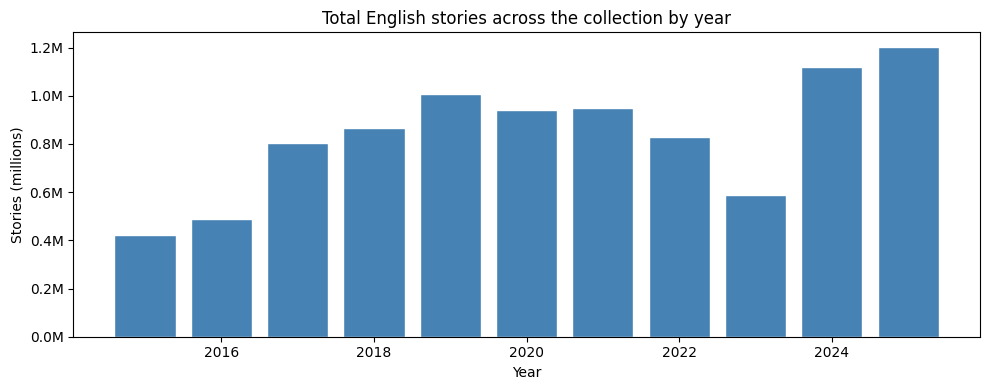

In [17]:
# --- Fig 2: Total stories aggregated across ALL sources by year ---
yearly_total = df.groupby("year")["matching_stories"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly_total.index, yearly_total.values / 1e6, color="steelblue", edgecolor="white")
ax.set_title("Total English stories across the collection by year")
ax.set_xlabel("Year")
ax.set_ylabel("Stories (millions)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
plt.tight_layout()
plt.show()


## 5. Consistency analysis — classify each source

Classify sources into tiers based on how consistently they publish across the 2015–2025 window. Key signals:
- **years_active**: how many of 11 years had any stories
- **cv** (coefficient of variation): measures year-to-year volatility relative to mean volume
- **years_sparse**: years with >0 but <500 stories (likely partial/incomplete indexing)


In [18]:
en_sources = df_summary[df_summary["primary_language"] == "en"].copy()

def classify(row):
    if row["years_active"] == N_YEARS and row["cv"] < 0.6 and row["years_sparse"] == 0:
        return "consistent"
    elif row["years_active"] >= 9 and row["cv"] < 1.2:
        return "mostly_consistent"
    elif row["years_active"] >= 7:
        return "partial"
    else:
        return "sparse_or_late"

en_sources["tier"] = en_sources.apply(classify, axis=1)

print("Tier breakdown:")
print(en_sources["tier"].value_counts())
print()
print("\n--- Consistent sources (best for full 2015-2025 analysis) ---")
print(en_sources[en_sources["tier"] == "consistent"][["total", "mean", "cv", "years_sparse"]].to_string())


Tier breakdown:
tier
mostly_consistent    45
partial              26
consistent            5
sparse_or_late        3
Name: count, dtype: int64


--- Consistent sources (best for full 2015-2025 analysis) ---
                      total     mean     cv  years_sparse
source                                                   
thestar.com          872804  79345.8  0.472             0
ctvnews.ca           805437  73221.5  0.554             0
globalnews.ca        568552  51686.5  0.296             0
brandonsun.com       278566  25324.2  0.417             0
theconversation.com  129459  11769.0  0.298             0


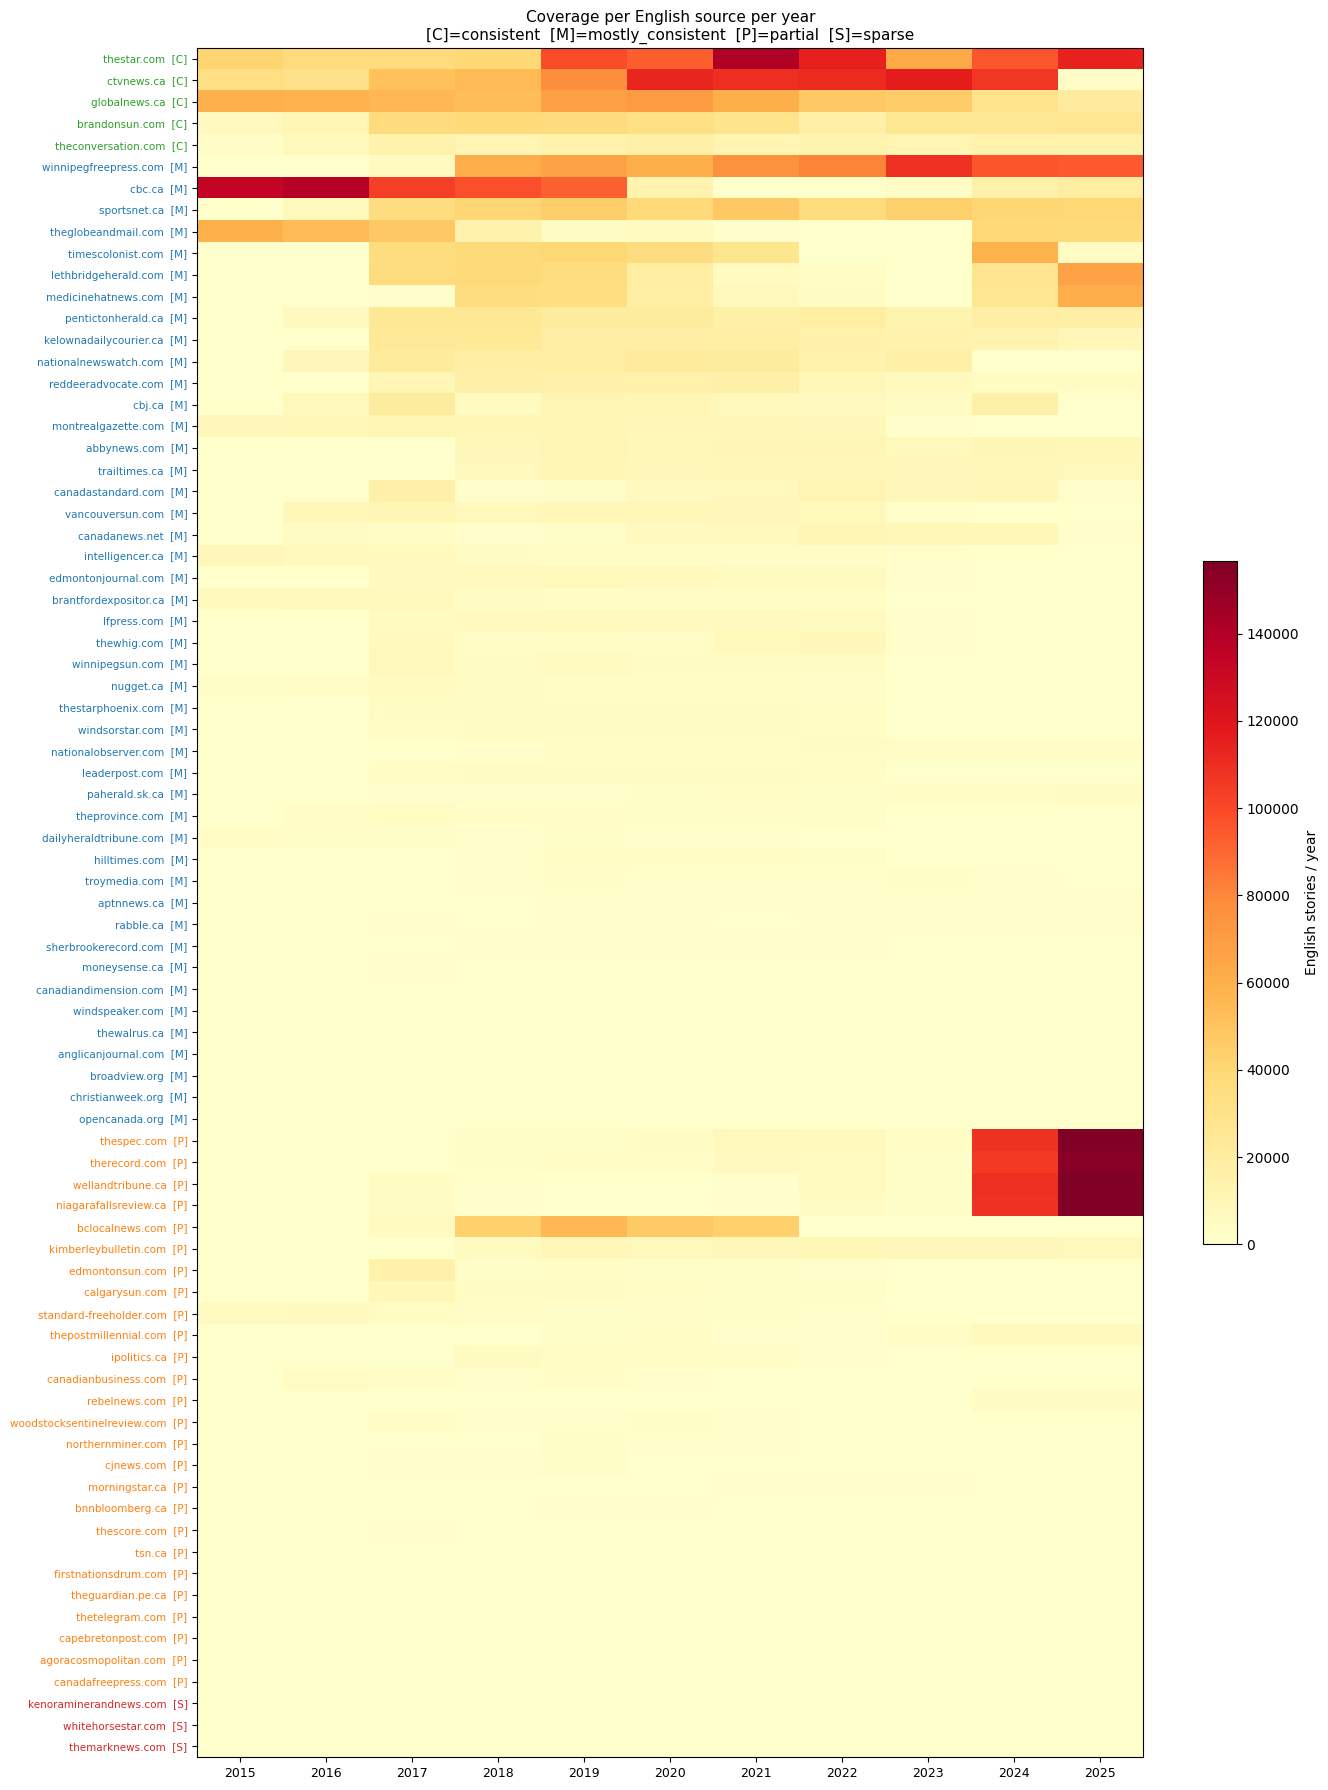

In [19]:
# --- Fig 3: Per-source coverage timeline (English sources, sorted by tier + total) ---
# Show each source's yearly count as a sparkline-style heatmap strip, coloured by tier

tier_order = ["consistent", "mostly_consistent", "partial", "sparse_or_late"]
tier_colors = {"consistent": "#2ca02c", "mostly_consistent": "#1f77b4", "partial": "#ff7f0e", "sparse_or_late": "#d62728"}

en_sources_ordered = en_sources.copy()
en_sources_ordered["tier_rank"] = en_sources_ordered["tier"].map({t: i for i, t in enumerate(tier_order)})
en_sources_ordered = en_sources_ordered.sort_values(["tier_rank", "total"], ascending=[True, False])

heat_en = df_pivot.loc[en_sources_ordered.index]

fig, ax = plt.subplots(figsize=(14, 18))
im = ax.imshow(
    heat_en.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=9)
ax.set_yticks(range(len(en_sources_ordered)))
ax.set_yticklabels(
    [f"{src}  [{tier[0].upper()}]" for src, tier in zip(en_sources_ordered.index, en_sources_ordered["tier"])],
    fontsize=7.5
)

# Colour ytick labels by tier
for label, tier in zip(ax.get_yticklabels(), en_sources_ordered["tier"]):
    label.set_color(tier_colors[tier])

plt.colorbar(im, ax=ax, label="English stories / year", shrink=0.4)
ax.set_title("Coverage per English source per year\n[C]=consistent  [M]=mostly_consistent  [P]=partial  [S]=sparse", fontsize=11)
plt.tight_layout()
plt.show()


## 6. Recommended usable year ranges per source

For each source find the contiguous block of years with meaningful coverage (≥500 stories/year), and flag the "safe" window to use.


In [20]:
SPARSE_THRESHOLD = 500  # articles/year below this = unreliable

recommendations = []
for source in en_sources_ordered.index:
    row_data = df_pivot.loc[source]
    # Find years with meaningful data
    good_years = [y for y in YEARS if row_data[y] >= SPARSE_THRESHOLD]
    
    if not good_years:
        rec_start, rec_end, n_good = None, None, 0
    else:
        # Find longest contiguous run
        best_run, cur_run = [], [good_years[0]]
        for y in good_years[1:]:
            if y == cur_run[-1] + 1:
                cur_run.append(y)
            else:
                if len(cur_run) > len(best_run):
                    best_run = cur_run
                cur_run = [y]
        if len(cur_run) > len(best_run):
            best_run = cur_run
        rec_start, rec_end = best_run[0], best_run[-1]
        n_good = len(best_run)

    recommendations.append({
        "source": source,
        "tier": en_sources.loc[source, "tier"],
        "total_stories": en_sources.loc[source, "total"],
        "years_active": en_sources.loc[source, "years_active"],
        "cv": en_sources.loc[source, "cv"],
        "rec_start": rec_start,
        "rec_end": rec_end,
        "n_usable_years": n_good,
        "sparse_years": [y for y in YEARS if 0 < row_data[y] < SPARSE_THRESHOLD],
        "zero_years": [y for y in YEARS if row_data[y] == 0],
    })

df_rec = pd.DataFrame(recommendations).set_index("source")
df_rec.to_csv(os.path.join(OUTPUT_DIR, "source_recommendations.csv"))

# Print tier summary
print("=== Sources usable for full 2015–2025 window ===")
full_window = df_rec[df_rec["n_usable_years"] == N_YEARS]
print(full_window[["tier", "total_stories", "cv", "rec_start", "rec_end"]].to_string())

print(f"\n=== Sources with ≥8 usable years ({len(df_rec[df_rec['n_usable_years'] >= 8])}) ===")
print(df_rec[df_rec["n_usable_years"] >= 8][["tier", "total_stories", "rec_start", "rec_end", "n_usable_years", "sparse_years"]].to_string())


=== Sources usable for full 2015–2025 window ===
                           tier  total_stories     cv  rec_start  rec_end
source                                                                   
thestar.com          consistent         872804  0.472     2015.0   2025.0
ctvnews.ca           consistent         805437  0.554     2015.0   2025.0
globalnews.ca        consistent         568552  0.296     2015.0   2025.0
brandonsun.com       consistent         278566  0.417     2015.0   2025.0
theconversation.com  consistent         129459  0.298     2015.0   2025.0

=== Sources with ≥8 usable years (27) ===
                                      tier  total_stories  rec_start  rec_end  n_usable_years        sparse_years
source                                                                                                           
thestar.com                     consistent         872804     2015.0   2025.0              11                  []
ctvnews.ca                      consistent      

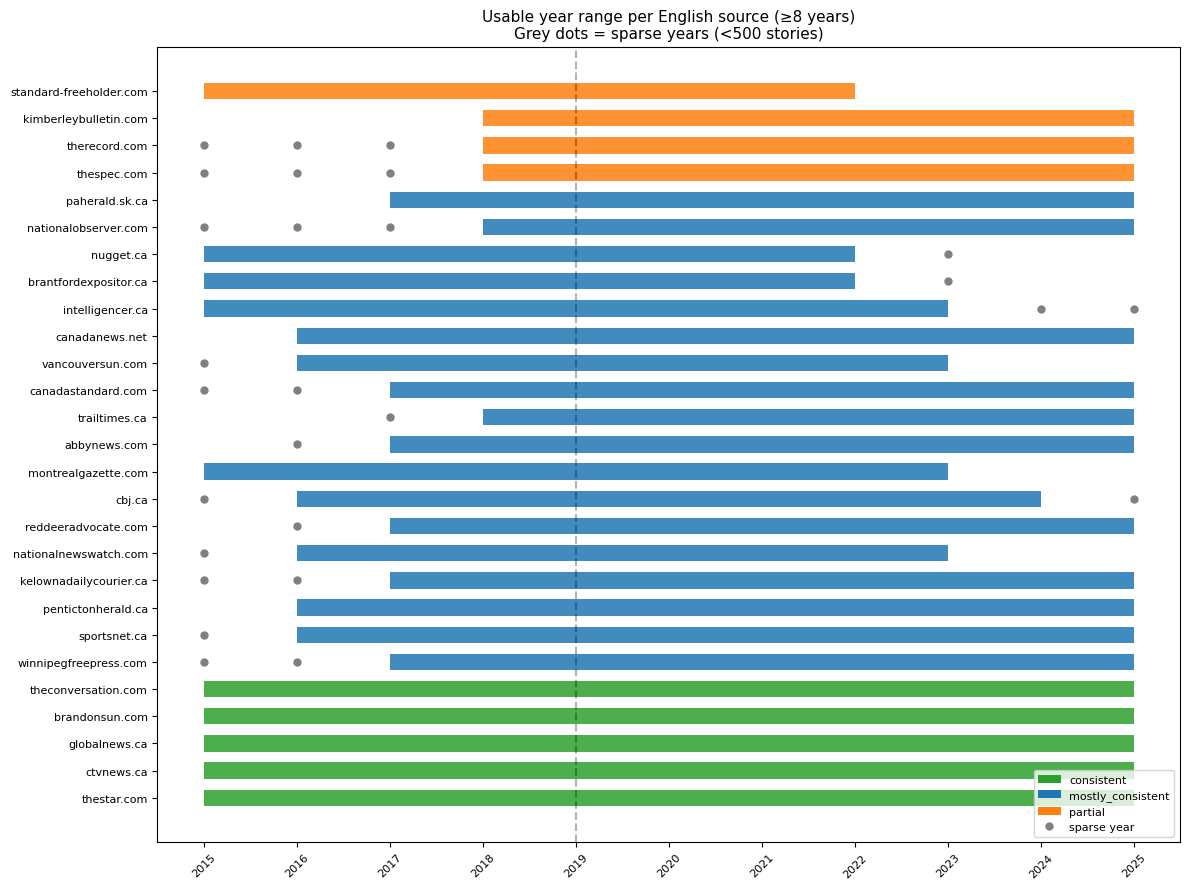

In [21]:
# --- Fig 4: Usable window per source (≥8 usable years), Gantt-style ---
usable = df_rec[df_rec["n_usable_years"] >= 8].sort_values(["tier", "total_stories"], ascending=[True, False])
tier_palette = {"consistent": "#2ca02c", "mostly_consistent": "#1f77b4", "partial": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(12, 9))
for i, (src, row) in enumerate(usable.iterrows()):
    color = tier_palette.get(row["tier"], "#999")
    ax.barh(i, row["rec_end"] - row["rec_start"], left=row["rec_start"], height=0.6,
            color=color, alpha=0.85)
    # Mark sparse years as grey dots
    for sy in row["sparse_years"]:
        ax.plot(sy, i, "o", color="grey", markersize=5, zorder=5)

ax.set_yticks(range(len(usable)))
ax.set_yticklabels(usable.index, fontsize=8)
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax.set_xticks(YEARS)
ax.set_xticklabels(YEARS, rotation=45, fontsize=8)
ax.set_title("Usable year range per English source (≥8 years)\nGrey dots = sparse years (<500 stories)", fontsize=11)
ax.axvline(2019, color="black", linestyle="--", alpha=0.3, label="2019 reference")

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="#2ca02c", label="consistent"),
    Patch(facecolor="#1f77b4", label="mostly_consistent"),
    Patch(facecolor="#ff7f0e", label="partial"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="grey", markersize=7, label="sparse year"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


## 7. Summary & recommendations


In [22]:
print("=" * 60)
print("COLLECTION: Canada - National (ID 34411583)")
print(f"Total English articles 2015-2025: {df['matching_stories'].sum():,.0f}")
print(f"English sources: {len(en_sources)} / {len(df_summary)} total sources")
print()
print("--- TIER COUNTS (English sources only) ---")
print(en_sources["tier"].value_counts().to_string())
print()
print("--- FULL 2015-2025 WINDOW (5 sources) ---")
for src in df_rec[df_rec["n_usable_years"] == N_YEARS].index:
    row = df_rec.loc[src]
    print(f"  {src:35s}  total={row['total_stories']:>7,}  cv={row['cv']:.2f}")
print()
print("--- PARTIAL WINDOW ISSUES ---")
print("  Many sources only started being consistently indexed from 2017+ onward.")
print("  thespec.com / therecord.com / wellandtribune.ca / niagarafallsreview.ca")
print("  show massive jumps in 2024-2025 (likely a bulk re-ingest of archive content)")
print()
print("--- RECOMMENDED APPROACH ---")
print("  Option A: Use 5 'consistent' sources for full 2015-2025 analysis.")
print("  Option B: Restrict to 2017-2023 window → 27 sources with reliable data.")
print("  Option C: Use all sources but restrict each to its 'rec_start'–'rec_end' window.")
print()
print("Saved files:")
print(f"  {OUTPUT_DIR}/coverage_per_source_per_year.csv")
print(f"  {OUTPUT_DIR}/coverage_pivot.csv")
print(f"  {OUTPUT_DIR}/source_summary.csv")
print(f"  {OUTPUT_DIR}/source_recommendations.csv")


COLLECTION: Canada - National (ID 34411583)
Total English articles 2015-2025: 9,217,879
English sources: 79 / 108 total sources

--- TIER COUNTS (English sources only) ---
tier
mostly_consistent    45
partial              26
consistent            5
sparse_or_late        3

--- FULL 2015-2025 WINDOW (5 sources) ---
  thestar.com                          total=872,804  cv=0.47
  ctvnews.ca                           total=805,437  cv=0.55
  globalnews.ca                        total=568,552  cv=0.30
  brandonsun.com                       total=278,566  cv=0.42
  theconversation.com                  total=129,459  cv=0.30

--- PARTIAL WINDOW ISSUES ---
  Many sources only started being consistently indexed from 2017+ onward.
  thespec.com / therecord.com / wellandtribune.ca / niagarafallsreview.ca
  show massive jumps in 2024-2025 (likely a bulk re-ingest of archive content)

--- RECOMMENDED APPROACH ---
  Option A: Use 5 'consistent' sources for full 2015-2025 analysis.
  Option B: Restri